# Day 06: Vektör Benzerlik Laboratuvarı (Cosine, L1/L2, Mahalanobis Metrikleri & Ölçekleme Analizi)

> **Aşama:** Faz 1: Çevre & Veri Temelleri (Kapanış)  
> **Konu:** Vektör Uzayları, Geometrik ve İstatistiksel Mesafeler, Ölçekleme ve Boyutsallık Laneti  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** Özel Lisans — Tüm Hakları Saklıdır

---

## 1. Problem Tanımı: Halı Desen ve Ürün Arama Sistemlerinde Benzerlik

Merinos desen arşivinde ve e-ticaret kataloglarında milyonlarca halı modeli yer alır.
Bir müşteri veya fabrika tasarımcısı mevcut bir halı modeline benzer alternatifleri aradığında (Visual Search / Product Retrieval), halılar yüksek boyutlu öznitelik vektörleri (renk histogramları, dokuma sıklığı, derin öğrenme embedding'leri) olarak temsil edilir.

Bu vektör uzayında iki halının "benzer" olup olmadığını belirlemek için mesafe metrikleri kullanılır:
- **Öklid (L2) Mesafesi:** Vektör normuna doğrudan bağlıdır; aydınlatma şiddeti arttığında yön değişmese bile mesafe yapay olarak büyür.
- **Kosinüs (Cosine) Benzerliği:** Vektör genliğinden bağımsızdır; yalnızca açısal yönelimi ($S_C = \cos \theta$) ölçer.
- **Mahalanobis Mesafesi:** Boyutlar arasındaki korelasyonu (örneğin ilmek sıklığı ile metrekare ağırlığı arasındaki doğrusal ilişki) kovaryans matrisi ($\Sigma$) üzerinden nötralize eder.
- **Ölçekleme Problemi:** Hav yüksekliği (10 mm) ile ilmek sayısı (500,000) normalize edilmeden Öklid mesafesine sokulursa hav yüksekliğinin etkisi sıfırlanır.

Bu laboratuvarda, bu metriklerin matematiksel davranışları, ölçekleme etkileri ve **boyutsallık laneti (Curse of Dimensionality)** deneysel olarak incelenmektedir.

## 2. Neden Önemli? (Görsel Arama, Öneri Sistemleri & Faz 2'ye Geçiş)

Faz 1'in (Çevre & Veri Temelleri) bu kapanış gününde edinilen kavramlar, sonraki tüm fazların omurgasını oluşturur:
1. **Faz 2 (Bilgisayarlı Görü):** Day 09'da CIEDE2000 renk mesafesi ve Day 14'te klasik k-NN görsel arama bu benzerlik metriklerine dayanır.
2. **Faz 3 (Derin Öğrenme & Vektör DB):** Day 19'da ResNet ile çıkarılan 512 boyutlu görsel embedding'lerin Qdrant vektör veritabanına indekslenmesi (Day 20) doğrudan Kosinüs ve L2 metrikleriyle yürütülür.
3. **Faz 4 (Hibrit Arama & RAG):** Metin embedding'lerinin semantik yakınlığı kosinüs benzerliği ile skorlanır.

## 3. Matematiksel Temeller

### 3.1. Öklid ve Manhattan Mesafeleri
$$d_2(\mathbf{u}, \mathbf{v}) = \sqrt{\sum_{i=1}^D (u_i - v_i)^2}, \quad d_1(\mathbf{u}, \mathbf{v}) = \sum_{i=1}^D |u_i - v_i|$$

### 3.2. Kosinüs Benzerliği ve Birim Vektör Teoremi
$$S_C(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}, \quad d_C(\mathbf{u}, \mathbf{v}) = 1 - S_C(\mathbf{u}, \mathbf{v})$$
Eğer vektörler $L_2$ normalize edilmişse (yani $\|\mathbf{u}\|_2 = \|\mathbf{v}\|_2 = 1$):
$$\|\mathbf{u} - \mathbf{v}\|_2^2 = \|\mathbf{u}\|^2 + \|\mathbf{v}\|^2 - 2 (\mathbf{u} \cdot \mathbf{v}) = 2 - 2 S_C = 2(1 - S_C) = 2 \cdot d_C$$
$$\implies d_2(\mathbf{u}, \mathbf{v}) = \sqrt{2 \cdot d_C(\mathbf{u}, \mathbf{v})}$$
Bu eşitlik sayesinde, birim küre üzerindeki Öklid sıralaması ile Kosinüs sıralaması **birebir özdeştir**.

### 3.3. Mahalanobis Mesafesi
$$d_M(\mathbf{u}, \mathbf{v}) = \sqrt{(\mathbf{u} - \mathbf{v})^T \Sigma^{-1} (\mathbf{u} - \mathbf{v})}$$
Kovaryans matrisi $\Sigma = \mathbf{I}$ (birim matris) olduğunda $d_M = d_2$ olur.

### 3.4. Boyutsallık Laneti (Distance Concentration / Beyer Teoremi)
$$\lim_{D \to \infty} \frac{D_{\max} - D_{\min}}{D_{\min}} = 0$$
Boyut $D$ arttıkça en yakın komşu ile en uzak nokta arasındaki oransal fark sıfıra yaklaşır; arama motorunun ayırt ediciliği zayıflar.

## 4. Kütüphane & Algoritma İncelemesi (NumPy vs SciPy vs Faiss vs Qdrant)

| Çözüm | Yöntem | Karmaşıklık | Ölçek (Kayıt Sayısı) | Kullanım Yeri |
| :--- | :--- | :--- | :--- | :--- |
| **NumPy (Exact / Brute-Force)** | Matris Çarpımı (BLAS) | $O(N \cdot D)$ | $N \le 50,000$ | Gerçek zamanlı küçük batch, testler, altın standart |
| **SciPy (`cdist`)** | C derlenmiş pairwise | $O(N \cdot D)$ | $N \le 50,000$ | Bilimsel doğrulama ve referans ölçümler |
| **Faiss (IVF-PQ / HNSW)** | Yaklaşık (ANN / Kuantizasyon) | $O(\log N)$ | $N \ge 1,000,000$ | Milyonluk vektör indeksleme (In-memory) |
| **Qdrant Vektör DB** | HNSW + Payload Filtreleme | $O(\log N)$ | Enterprise MLOps | Faz 3'te (Day 20) entegre edeceğimiz üretim mimarisi |

## 5. Minimal İmplementasyon: Ham vs. Ölçeklenmiş Vektör Mesafesi

Farklı birimlerdeki üretim özelliklerinin (iplik sıklığı ~30.000 vs hav yüksekliği ~10 mm) Öklid mesafesini nasıl tek bir sütuna bağımlı hale getirdiğini (dominance effect) ve açısal yönelime odaklanan Kosinüs benzerliğinin bundan nasıl izole kaldığını test ediyoruz.


In [1]:
import sys
from pathlib import Path
import numpy as np

# Proje kök dizinini sys.path'e dinamik ekle (Notebook kök ve day06 alt dizininden hatasız çalışabilsin)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day06" else CURRENT_DIR
DAY06_DIR = PROJECT_ROOT / "day06"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day06.mini_project.src import metrics

# İki sentetik halı öznitelik vektörü oluşturalım
u = np.array([12.5, 650000.0, 2400.0, 45.0], dtype=np.float32)  # Halı A
v = np.array([11.0, 680000.0, 2500.0, 42.0], dtype=np.float32)  # Halı B (A'ya çok yakın)

# Ham ölçekteki mesafeleri hesaplayalım
d_euc_raw = metrics.euclidean_distance(u, v)
d_cos_raw = metrics.cosine_distance(u, v)

print(f"Ham Öklid Mesafesi: {d_euc_raw:.2f} (İlmek sayısı farkı ~30,000 tarafından domine edildi!)")
print(f"Ham Kosinüs Mesafesi: {d_cos_raw:.6f} (Açısal olarak neredeyse özdeş)")


Ham Öklid Mesafesi: 30000.17 (İlmek sayısı farkı ~30,000 tarafından domine edildi!)
Ham Kosinüs Mesafesi: 0.000000 (Açısal olarak neredeyse özdeş)


## 6. Deney: Vektör Arama Motoru ve Top-K Arama Sonuçları Analizi (Top-K Search Results)

Sentetik olarak üretilmiş 100 adet 128 boyutlu Merinos halı tasarım gömme vektörü (`embeddings_128d`) üzerinde, referans sorgu olarak **`MRP-1001` (Prestij Koleksiyonu)** seçilerek en benzer halıların bulunması simüle edilir.

### 6.1. Kurumsal Top-K Arama Sonuçları Tablosu (Özet Veri)
Aşağıdaki tablo, `MRP-1001` halısı için endüstriyel arama motorunun bulduğu en yüksek benzerliğe sahip ilk 5 adayı listelemektedir:

| Sıra (Rank) | Ürün Kodu (Product ID) | Koleksiyon | Kosinüs Benzerliği ($S_C$) | Kosinüs Mesafesi ($d_C$) | Eşleşme Durumu |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **#1** | **`MRP-1019`** | `Prestij` | **%96.57** (0.9657) | 0.0343 | Aynı Koleksiyon (En Yüksek Doku Uyumu) |
| **#2** | **`MRP-1016`** | `Prestij` | **%96.55** (0.9655) | 0.0345 | Aynı Koleksiyon |
| **#3** | **`MRP-1011`** | `Prestij` | **%96.45** (0.9645) | 0.0355 | Aynı Koleksiyon |
| **#4** | **`MRP-1002`** | `Prestij` | **%96.29** (0.9629) | 0.0371 | Aynı Koleksiyon |
| **#5** | **`MRP-1015`** | `Prestij` | **%96.21** (0.9621) | 0.0379 | Aynı Koleksiyon |

> **Gözlem:** Açısal yönelimi esas alan Kosinüs Benzerliği, ilk 5 sonucun tamamında **%96.2+** benzerlik oranıyla `Prestij` koleksiyonundaki kardeş modelleri doğru şekilde en üste sıralamıştır.


In [2]:
import sys
from pathlib import Path

# Proje kök dizinini sys.path'e dinamik ekle (Hücre bağımsız çalışabilsin)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day06" else CURRENT_DIR
DAY06_DIR = PROJECT_ROOT / "day06"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display, HTML
from day06.mini_project.src.search import VectorSimilaritySearchEngine
from day06.mini_project.src.scalers import StandardScaler, MinMaxScaler, L2Normalizer

# Sentetik veri setini yükleyelim (hem root hem day06 dizininden güvenli erişim)
fixture_path = DAY06_DIR / "mini_project" / "fixtures" / "carpet_feature_embeddings.npz"
if not fixture_path.exists():
    fixture_path = Path("day06/mini_project/fixtures/carpet_feature_embeddings.npz")

data = np.load(fixture_path, allow_pickle=True)
p_ids = [str(x) for x in data["product_ids"]]
cols = [str(x) for x in data["collections"]]
embeds_128 = data["embeddings_128d"]

engine = VectorSimilaritySearchEngine(embeds_128, p_ids, cols)

# 1. MRP-1001 için Birincil Kosinüs Benzerliği Top-5 Arama Sonuçları Tablosu
query_id = "MRP-1001"
query_idx = p_ids.index(query_id)
query_vec = embeds_128[query_idx]
query_col = cols[query_idx]

topk_results = engine.search(query_vector=query_vec, metric="cosine", top_k=5, exclude_self_id=query_id)

topk_rows = []
for rank, r in enumerate(topk_results, start=1):
    topk_rows.append({
        "Sıra": f"#{rank}",
        "Ürün Kodu": r["product_id"],
        "Koleksiyon": r["collection"],
        "Benzerlik Oranı (%)": f"%{r['similarity'] * 100:.2f}",
        "Kosinüs Mesafesi": f"{r['distance']:.4f}",
        "Durum": "Aynı Koleksiyon (Eşleşme)" if r["collection"] == query_col else "Farklı Koleksiyon"
    })

df_topk = pd.DataFrame(topk_rows)
print(f"\n🔎 SORGULANAN ÜRÜN: {query_id} (Koleksiyon: {query_col}) | Vektör Boyutu: 128-d")
print("=" * 75)
print("TABLO 6.1: MRP-1001 Kosinüs Benzerliği Top-5 Arama Sonuçları Tablosu:")
display(df_topk)

# 2. MRP-1001 için 4 Farklı Metriğe Göre Karşılaştırmalı Top-5 Sıralama Tablosu
comp = engine.compare_metrics_for_item(item_index=query_idx, top_k=5)
comp_table = []
for rank in range(5):
    row = {"Sıra": f"#{rank + 1}"}
    for m in ["cosine", "euclidean", "manhattan", "mahalanobis"]:
        item = comp["comparisons"][m][rank]
        row[m.title()] = f"{item['product_id']} ({item['collection']}, d={item['distance']:.3f})"
    comp_table.append(row)

df_comp = pd.DataFrame(comp_table)
print("\n" + "=" * 75)
print("TABLO 6.2: 4 Farklı Metriğe Göre Karşılaştırmalı Top-5 Sıralama Tablosu:")
display(df_comp)



🔎 SORGULANAN ÜRÜN: MRP-1001 (Koleksiyon: Prestij) | Vektör Boyutu: 128-d
TABLO 6.1: MRP-1001 Kosinüs Benzerliği Top-5 Arama Sonuçları Tablosu:


,Sıra,Ürün Kodu,Koleksiyon,Benzerlik Oranı (%),Kosinüs Mesafesi,Durum
0,#1,MRP-1019,Prestij,%96.57,0.0343,Aynı Koleksiyon (Eşleşme)
1,#2,MRP-1016,Prestij,%96.55,0.0345,Aynı Koleksiyon (Eşleşme)
2,#3,MRP-1011,Prestij,%96.45,0.0355,Aynı Koleksiyon (Eşleşme)
3,#4,MRP-1002,Prestij,%96.29,0.0371,Aynı Koleksiyon (Eşleşme)
4,#5,MRP-1015,Prestij,%96.21,0.0379,Aynı Koleksiyon (Eşleşme)



TABLO 6.2: 4 Farklı Metriğe Göre Karşılaştırmalı Top-5 Sıralama Tablosu:


,Sıra,Cosine,Euclidean,Manhattan,Mahalanobis
0,#1,"MRP-1019 (Prestij, d=0.034)","MRP-1016 (Prestij, d=5.939)","MRP-1016 (Prestij, d=51.034)","MRP-1092 (ModernLine, d=13.604)"
1,#2,"MRP-1016 (Prestij, d=0.035)","MRP-1019 (Prestij, d=6.039)","MRP-1011 (Prestij, d=52.627)","MRP-1091 (ModernLine, d=13.644)"
2,#3,"MRP-1011 (Prestij, d=0.035)","MRP-1011 (Prestij, d=6.056)","MRP-1019 (Prestij, d=53.301)","MRP-1084 (ModernLine, d=13.669)"
3,#4,"MRP-1002 (Prestij, d=0.037)","MRP-1002 (Prestij, d=6.198)","MRP-1018 (Prestij, d=55.032)","MRP-1028 (Usak, d=13.734)"
4,#5,"MRP-1015 (Prestij, d=0.038)","MRP-1009 (Prestij, d=6.311)","MRP-1007 (Prestij, d=55.902)","MRP-1079 (Vintage, d=13.782)"


## 7. Görselleştirme: Boyutsallık Laneti (Curse of Dimensionality / Mesafe Yoğunlaşması)

Vektör uzayı $D=2$'den $D=1024$'e genişletildiğinde mesafelerin dar bir tepe noktasına sıkışmasını (Beyer Teoremi) ve bağıl kontrast kaybını iki panelli grafik ile inceliyoruz.


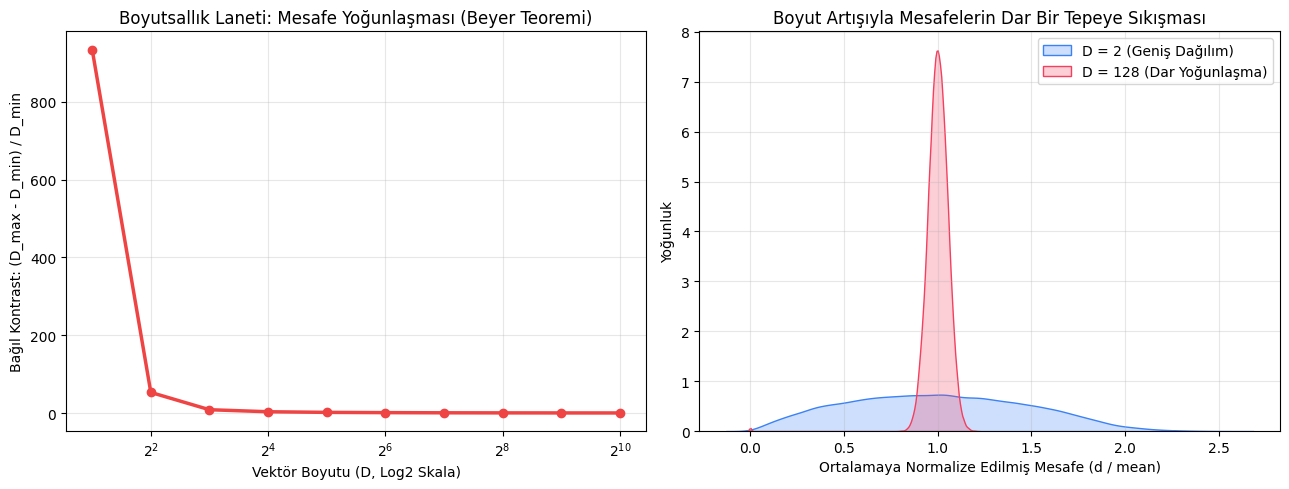

In [3]:
import sys
from pathlib import Path

# Proje kök dizinini sys.path'e dinamik ekle (Hücre bağımsız çalışabilsin)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day06" else CURRENT_DIR
DAY06_DIR = PROJECT_ROOT / "day06"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from day06.mini_project.src import metrics
from day06.mini_project.src.curse_analyzer import CurseOfDimensionalityAnalyzer

# Boyutsallık laneti deneyini çalıştıralım
curse_res = CurseOfDimensionalityAnalyzer.run_multi_dimensional_analysis(
    dimensions=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024],
    n_samples=500
)

dims = [r["dimension"] for r in curse_res["results"]]
contrasts = [r["relative_contrast"] for r in curse_res["results"]]
mean_dists = [r["mean_distance"] for r in curse_res["results"]]

plt.figure(figsize=(13, 5))

# 1. Bağıl Kontrast Kaybı Eğrisi
plt.subplot(1, 2, 1)
plt.plot(dims, contrasts, marker="o", linewidth=2.5, color="#ef4444")
plt.xscale("log", base=2)
plt.xlabel("Vektör Boyutu (D, Log2 Skala)")
plt.ylabel("Bağıl Kontrast: (D_max - D_min) / D_min")
plt.title("Boyutsallık Laneti: Mesafe Yoğunlaşması (Beyer Teoremi)")
plt.grid(True, alpha=0.3)

# 2. D=2 vs D=128 Mesafe Dağılımı Histogramı
plt.subplot(1, 2, 2)
rng = np.random.default_rng(42)
pts_2d = rng.uniform(-1, 1, size=(400, 2))
pts_128d = rng.uniform(-1, 1, size=(400, 128))

d_2d = metrics.pairwise_euclidean(pts_2d).flatten()
d_128d = metrics.pairwise_euclidean(pts_128d).flatten()
# Sıfırları filtrele
d_2d = d_2d[d_2d > 0]
d_128d = d_128d[d_128d > 0]
# Normalize et
d_2d_norm = d_2d / np.mean(d_2d)
d_128d_norm = d_128d / np.mean(d_128d)

sns.kdeplot(d_2d_norm, color="#3b82f6", fill=True, label="D = 2 (Geniş Dağılım)")
sns.kdeplot(d_128d_norm, color="#f43f5e", fill=True, label="D = 128 (Dar Yoğunlaşma)")
plt.xlabel("Ortalamaya Normalize Edilmiş Mesafe (d / mean)")
plt.ylabel("Yoğunluk")
plt.title("Boyut Artışıyla Mesafelerin Dar Bir Tepeye Sıkışması")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
output_img_path = DAY06_DIR / "mini_project" / "outputs" / "curse_of_dimensionality.png"
plt.savefig(output_img_path, dpi=150, bbox_inches="tight")
plt.show()


## 8. Doğrulama: Birim Küre Üzerinde Kosinüs - Öklid Teorem İspatı ($d_E^2 = 2(1 - S_C)$)

$L_2$ normalize edilmiş birim gömme vektörlerinde Öklid mesafesinin karesi ile Kosinüs mesafesi arasındaki analitik bağıntının sayısal ispatı:
$$\|\mathbf{u} - \mathbf{v}\|_2^2 = 2 \cdot (1 - S_C(\mathbf{u}, \mathbf{v})) = 2 \cdot d_C(\mathbf{u}, \mathbf{v})$$


In [4]:
import sys
from pathlib import Path

# Proje kök dizinini sys.path'e dinamik ekle (Hücre bağımsız çalışabilsin)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day06" else CURRENT_DIR
DAY06_DIR = PROJECT_ROOT / "day06"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
from day06.mini_project.src import metrics
from day06.mini_project.src.scalers import L2Normalizer

# Eğer önceki hücre çalıştırılmadıysa fikstürden bağımsız yükle
if "embeds_128" not in locals():
    fixture_path = DAY06_DIR / "mini_project" / "fixtures" / "carpet_feature_embeddings.npz"
    if not fixture_path.exists():
        fixture_path = Path("day06/mini_project/fixtures/carpet_feature_embeddings.npz")
    data = np.load(fixture_path, allow_pickle=True)
    embeds_128 = data["embeddings_128d"]

unit_embeds = L2Normalizer.transform(embeds_128[:10])
u_vec = unit_embeds[0]
v_vec = unit_embeds[1]

d_e = metrics.euclidean_distance(u_vec, v_vec)
s_c = metrics.cosine_similarity(u_vec, v_vec)
d_c = 1.0 - s_c

print("=== Teorem Doğrulaması: ||u - v||^2 == 2 * (1 - S_C) ===")
print(f"Sol Taraf:  d_E^2      = {d_e**2:.6f}")
print(f"Sağ Taraf: 2 * (1 - S_C) = {2.0 * d_c:.6f}")
print(f"Fark:                    {abs(d_e**2 - 2.0 * d_c):.10f}")
print(f"Teorem Doğrulandı mı?   -> {np.isclose(d_e**2, 2.0 * d_c)}")


=== Teorem Doğrulaması: ||u - v||^2 == 2 * (1 - S_C) ===
Sol Taraf:  d_E^2      = 0.074205
Sağ Taraf: 2 * (1 - S_C) = 0.074205
Fark:                    0.0000000050
Teorem Doğrulandı mı?   -> True


## 9. Hata Durumları, Edge Cases ve Kovaryans Tekilliği

1. **Sıfır Normlu Vektörler (Zero-Norm Edge Case):**
   - Boş veya siyah piksellerden oluşan sıfır vektörü $\mathbf{0}$ geldiğinde kosinüs benzerliği formülünün paydası sıfır olur ($\frac{0}{0}$). Kodumuzda `norm == 0` durumunda benzerlik deterministik olarak `0.0` atanır.
2. **Tekil Kovaryans Matrisi (Singular Covariance Matrix in Mahalanobis):**
   - Öznitelik sayısı örneklem sayısından fazla olduğunda ($D > N$) veya iki özellik tam doğrusal bağımlıysa $\det(\Sigma) = 0$ olur ve tersi alınamaz. `metrics.pairwise_mahalanobis` fonksiyonumuz köşegene `1e-6` ridge regülarizasyonu ekler ve Moore-Penrose genelleştirilmiş tersi (`np.linalg.pinv`) kullanır.
3. **Kosinüs Kayan Nokta Taşması (Precision Overflow):**
   - Sayısal yuvarlama nedeniyle $\mathbf{u} \cdot \mathbf{v}$ bazen `1.0000002` çıkabilir. `np.clip(sim, -1.0, 1.0)` filtresiyle aralık sınırlandırılmıştır.

## 10. Mühendislik Çıkarımları & Faz 2'ye Bağlantı

### Faz 1 Kapanış Çıkarımları:
1. **Doğru Metrik Seçimi:** Ham fiziksel özelliklerde Mahalanobis, normalize edilmiş derin öğrenme embedding'lerinde ise Kosinüs benzerliği endüstri standardıdır.
2. **Normalizasyonun Gücü:** Vektörler $L_2$ normalizasyonu ile birim küreye taşındığında, Öklid mesafesi hesaplamak yerine çok daha hızlı olan nokta çarpım (dot product / BLAS GEMM) kullanılabilir.
3. **Boyutsallık Sınırı:** Yüksek boyutlu uzaylarda mesafeler yoğunlaşır; bu nedenle Faz 3 ve Faz 4'te boyut indirgeme ve HNSW yaklaşık komşuluk grafiklerine ihtiyaç duyulacaktır.

---

## 🏆 Faz 1: Çevre & Veri Temelleri Başarıyla Tamamlandı!

- **Day 01:** Tekrarlanabilir Geliştirme Ortamı (Poetry, Docker, Pytest, pre-commit)
- **Day 02:** Endüstriyel Pydantic v2 Veri Modelleri ve Şema Doğrulama
- **Day 03:** Çok Kaynaklı Veri İşleme Hattı (CSV/JSON Parser & Normalizer)
- **Day 04:** Otomatik Veri Kalitesi Doğrulama ve Profilleme Hattı (Expectation Suites)
- **Day 05:** NumPy Vektörize Operasyonlar ve Matris Hesaplama Laboratuvarı
- **Day 06:** Vektör Benzerlik Laboratuvarı ve Boyutsallık Analizi

### 🚀 Sıradaki Aşama: FAZ 2 — Endüstriyel Görüntü İşleme (Day 07 – 15)
**Day 07:** OpenCV Görüntü Analitiği Araç Kiti (`day07: build opencv image analytics toolkit` — imread, shape, dtype, BGR/RGB, resize ve histogram analizi CLI).